In [ ]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from scipy.stats import norm
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
base_path = Path('/content/drive/Shareddrives/KN Solvro/03. Projekty/Wakacyjne Wyzwanie 20256/ML/notebooki/1_Przetwarzanie i wizualizacja danych') # change path here!

# Klasyfikacja pasażerów Titanica


In [ ]:
data_path= '/content/drive/MyDrive/ML-wakacyjne-wyzwanie-2026/titanic.csv'
titanic_df = pd.read_csv(data_path, index_col='PassengerId')

# Obserwacje z poprzedniego zadania



Z pierwszego zadania wywnioskowałam, że niektóre atrybuty powinny mieć zmieniony typ a inne powinny zostać usunięte. Ponadto stworzyłam dwie kolumny Country i Age_group.

Niektóre kolumny posiadły brakujące dane, więc należało je uzupełnić. Jednak po sprawdzeniu zadania dowiedziałam się, że zamiast losowego uzupełniania danych brakujących w Age i Fare powinnam użyć np mediany, ale osobno na zbiorze uczącym i trenigowym. Po obserwacji danych zmieniłabym także zmienną Cabin na pierwszą literę kajuty, aby kodowanie nie zanieczysciło nam danych.

Teraz przekształcę nasze dane, aby były gotowe dla modeli, bazując kodzie z zadania 1 ulopszonym o uwagi mi dane.




In [ ]:
#Usuwanie kolumn Name i Ticket
titanic_df.drop(columns=["Name","Ticket"], inplace=True)

In [ ]:
#Zmienne kategorialne porządkowe
titanic_df['Sex']=titanic_df['Sex'].astype('category')
titanic_df['Embarked']=titanic_df['Embarked'].astype('category')

#Uzupełnianie danych brakujących dla Cabin
titanic_df['Cabin']=titanic_df['Cabin'].fillna("Unknown")


In [ ]:
#Nowe kolumny
countries={"C":"France",
       "Q":"Irland",
       "S":"England"}
titanic_df["Country"]=titanic_df['Embarked'].map(countries)

def agegroup(age):
  if age<=18:
    return "Child"
  elif age>60:
    return "Senior"
  else:
    return "Adult"

titanic_df["Age_group"]=titanic_df["Age"].apply(agegroup)

In [ ]:
#Zmiana Cabin przed zakodowaniem
titanic_df['Cabin']=titanic_df['Cabin'].str[0]


I tutaj stworzyłabym podział na zbiór trenigowy i testowy

In [ ]:
y = titanic_df["Survived"]
X = titanic_df.drop(columns=["Survived"])

X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8,shuffle=True,random_state=25,stratify=y)


In [ ]:
#Uzupełnienie reszty braków danych
# wartości wyliczamy WYŁĄCZNIE z X_train

agem = X_train["Age"].median()
farem = X_train["Fare"].median()
embarkedm = X_train["Embarked"].mode()[0]
X_train["Age"] = X_train["Age"].fillna(agem)
X_train["Fare"] = X_train["Fare"].fillna(farem)
X_train["Embarked"] = X_train["Embarked"].fillna(embarkedm)

# test - używamy wartości poznanych z train
X_test["Age"] = X_test["Age"].fillna(agem)
X_test["Fare"] = X_test["Fare"].fillna(farem)
X_test["Embarked"] = X_test["Embarked"].fillna(embarkedm)


W zadaniu pierwszym zrobiłam tylko heatmapę bez zależności między survived a poszczególnymi atrybutami. Jednak teraz widzę, że było to potrzebne, dlatego umieszczę je teraz(będą one w jednej komórce, aby nie zaśmiecać pracy wykresami, które powinny się pojawić w zadaniu 1)

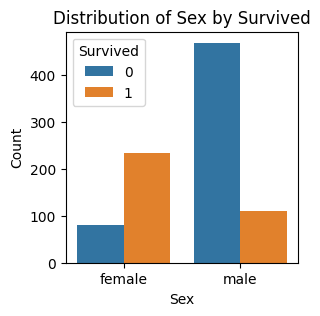

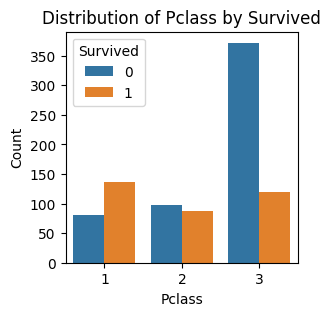

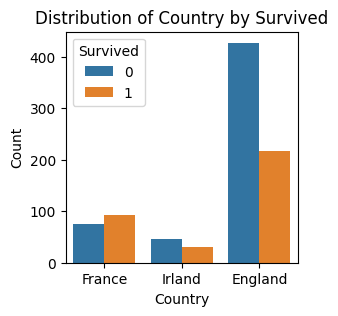

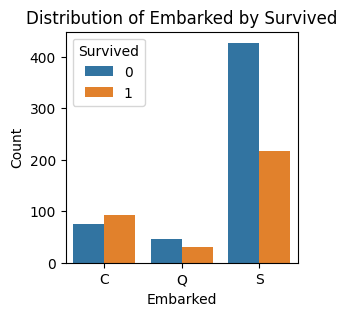

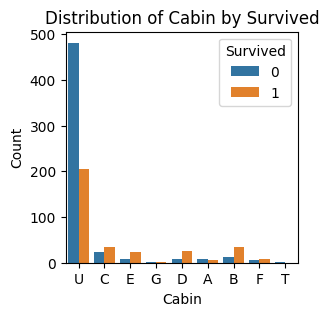

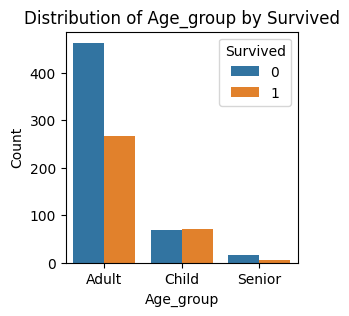

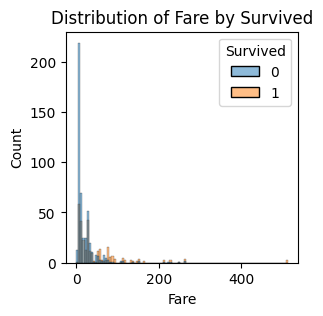

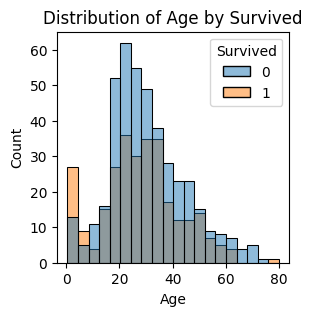

In [ ]:
def plot_categorical_column(df, column_name):
    plt.figure(figsize=(3, 3))
    sns.countplot(data=titanic_df, x=column_name, hue='Survived')
    plt.title(f'Distribution of {column_name} by Survived')
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()
plot_categorical_column(titanic_df, 'Sex')
plot_categorical_column(titanic_df, 'Pclass')
plot_categorical_column(titanic_df, 'Country')
plot_categorical_column(titanic_df, 'Embarked')
plot_categorical_column(titanic_df, 'Cabin')
plot_categorical_column(titanic_df, 'Age_group')

def plot_numeric(df, column_name):
    plt.figure(figsize=(3, 3))
    sns.histplot(data=titanic_df, x=column_name, hue='Survived')
    plt.title(f'Distribution of {column_name} by Survived')
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()
plot_numeric(titanic_df, 'Fare')
plot_numeric(titanic_df, 'Age')





Mając te wykresy jesteśmy w stanie zauważyć, że najbardziej na przeżycie wpływa płeć pasażera, wiek/ przedział wiekowy oraz klasa podróży/ cena biletu. Z tego co wiemy o Tytanicu to nie są to odkrywcze wnioski, aczkolwiek należało je tu umieścić, gdyż pozwolą nam zauważyć co jest bardzo ważne w modelu.


Na końcu należało także zakodować cechy kategorialne, aby algorytmy uczenia maszynowego były w stanie je zrozumieć.

In [ ]:
#Encoding
X_train = pd.get_dummies(data=X_train, prefix='Cabin', columns=['Cabin'], dtype=np.int32)
X_test = pd.get_dummies(data=X_test, prefix='Cabin', columns=['Cabin'], dtype=np.int32)
X_train = pd.get_dummies(data=X_train, prefix='Embarked', columns=['Embarked'], dtype=np.int32)
X_test = pd.get_dummies(data=X_test, prefix='Embarked', columns=['Embarked'], dtype=np.int32)
X_train = pd.get_dummies(data=X_train, prefix='Sex', columns=['Sex'], dtype=np.int32)
X_test = pd.get_dummies(data=X_test, prefix='Sex', columns=['Sex'], dtype=np.int32)
X_train = pd.get_dummies(data=X_train, prefix='Country', columns=['Country'], dtype=np.int32)
X_test = pd.get_dummies(data=X_test, prefix='Country', columns=['Country'], dtype=np.int32)
wiek={"Child":1,
      "Adult":2,
      "Senior":3}
X_train['Age_group']=X_train['Age_group'].map(wiek)
X_test['Age_group']=X_test['Age_group'].map(wiek)

X_train, X_test = X_train.align(X_test,join="left",axis=1,fill_value=0)


# Modele



Do porównywania naszych modeli i ich wariantów będziemy używać precyzji(precision), która sposród wszystkich przewidzianych uratowanych wyznacza procent tych którzy faktycznie przetrwali oraz czułości(recall), która wskazuje jaki procent przetrwałych wyłapał ze wszystkich nasz model. Te dwie metryki kontrolują siebie nawzajem, aby nasz model bezmyślnie nie przepisywał wszystkich jako pasażerów, którzy przeżyli. Ponadto najbardziej zależy nam na wykluczeniu przypadków, gdzie ten kto ocalił został przypisany jako martwy.

Aby wyniki modeli przy każdym uruchmianiu były takie same musimy ustawić random_state.

Najpierw, żeby mieć do czego porównywać stworzę Dummy Classifier.
Będzie miał on startegię most_frequent, ponieważ rozkład naszych klas jest nierównomierny. Najprostszy model będzie na początku ślepo podążał za rozkładem. W tym przypadku taki wybór jest najbezpieczniejszy.

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.61      1.00      0.76       110
           1       0.00      0.00      0.00        69

    accuracy                           0.61       179
   macro avg       0.31      0.50      0.38       179
weighted avg       0.38      0.61      0.47       179



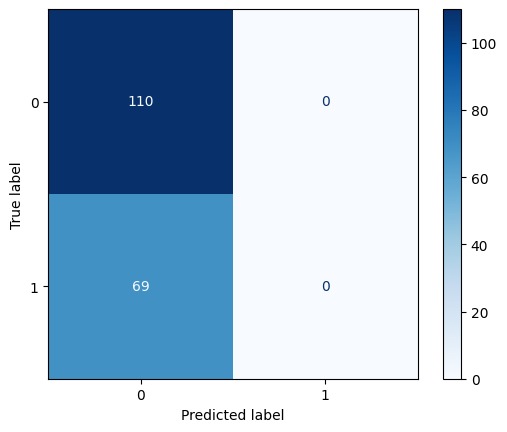

In [ ]:
model = DummyClassifier(strategy = 'most_frequent',random_state=25)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
cm=confusion_matrix(y_test, y_pred)
def plot_confusion_matrix(cm,model):
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=model.classes_)
  disp.plot(cmap="Blues")
  plt.show()
plot_confusion_matrix(cm,model)


Dla osób, którym udało się przetrwać DummyClasifier na zbiorze testowym ma czułość i precyzję na poziomie *0%*. Dodatkowo dokładność wynosi dokładnie *61%*. Nasz model uznaje wszystkich jako zmarłych, a zracji tego, że ich było więcej niż ocalałych to nasz model ma dokładność na tak wysokim poziomie. Nie jest to rewelacyjny wynik, ale będzie on stanowił dla nas "próg".

              precision    recall  f1-score   support

           0       0.62      1.00      0.76       439
           1       0.00      0.00      0.00       273

    accuracy                           0.62       712
   macro avg       0.31      0.50      0.38       712
weighted avg       0.38      0.62      0.47       712



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


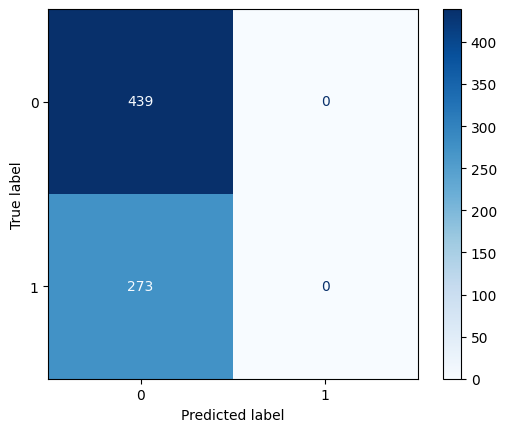

In [ ]:
y_pred_train = model.predict(X_train)
print(classification_report(y_train, y_pred_train))
cm0=confusion_matrix(y_train, y_pred_train)
plot_confusion_matrix(cm0,model)

Na zbiorze treningowym dokładność to *62%*. Precyzja oraz czułość dla ocalałych wynoszą *0%*. Nie jest to niczym nadzwyczajnym, a mamy stworzony baseline, który mówi nam, jakie przypisanie wszystkich jako zmarłych (liczniejszej klasy) daje efekty.


**1.   Drzewo decyzyjne**




Warto na początek zauważyć, że w przypadku drzew klasyfikacyjnych nie potrzebujemy dokonywać standaryzacji. Drzewa bedą poprawnie działać bez tego procesu.

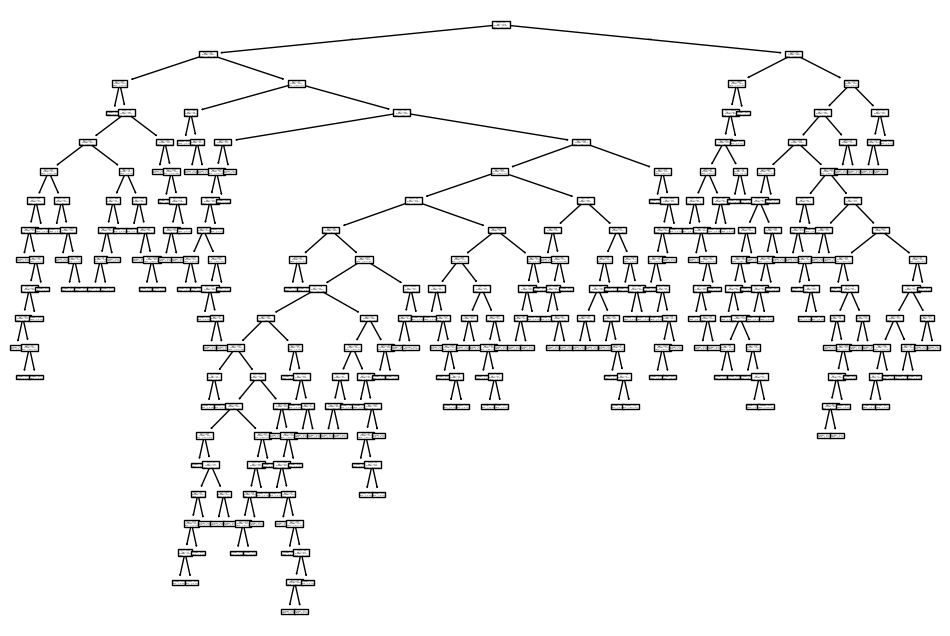

In [ ]:
model1 = DecisionTreeClassifier(random_state=25)
model1.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
tree.plot_tree(model1, proportion=True)
plt.show()


Bez ustalonych hiperparametrów nasze drzewo wygląda bardzo chaotycznie. Aczkolwiek, dzięki temu rysunkowi jesteśmy w stanie zrozumieć działanie drzewa. Wpierw model przypisuje jednostkę do liczniejszej klasy. Następnie na podstawie zaobserwowancyh wzorców i zasad, algorytm decyduje co dalej. Taki proces powtarzany jest, aż do ostatniego liścia w gałęzi, do której trafiła jednostka.




              precision    recall  f1-score   support

           0       0.83      0.86      0.84       110
           1       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



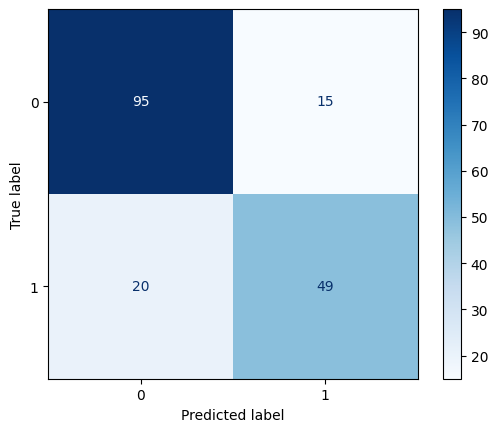

In [ ]:
y_pred1 = model1.predict(X_test)
print(classification_report(y_test, y_pred1))
cm1=confusion_matrix(y_test, y_pred1)
plot_confusion_matrix(cm1,model1)

Jak możemy zauważyc nasze podstawowe drzewo dla zbioru testowego jest dużo lepsze niż poprzedni klasyfikator. 90 pasażerów prawidłowo zostało uznanych za zmarłych. 48 ocalałych zostało poprawnie sklasyfikowanych. 19 osób błednie uśmiercono, a 22 przywrócono do życia. Dokładność drzewa wynosi *80%*. Jego precyzja to dla przetrwałych to *77%*, a czułość *71%*. Model radzi sobie lepiej niż DummyClasifier.

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       439
           1       1.00      0.96      0.98       273

    accuracy                           0.98       712
   macro avg       0.99      0.98      0.98       712
weighted avg       0.98      0.98      0.98       712



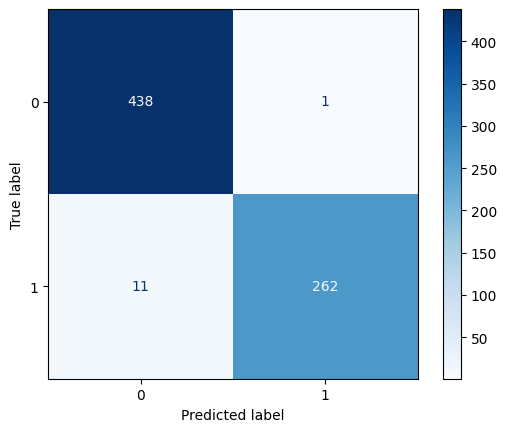

In [ ]:
y_pred1 = model1.predict(X_train)
print(classification_report(y_train, y_pred1))
cm11=confusion_matrix(y_train, y_pred1)
plot_confusion_matrix(cm11,model1)

Patrząc na dokładność zbioru treningowego, która wynosi aż *98%*. Mamy więc do czynienia z przeuczeniem. Może być to spowodowane brakiem ograniczeń dla naszego drzewa. Dodatkowo na tym etapie nie ma sensu badać modelu poprzez cross-validation. Ustalmy więc hiperparametry, które naprawią nasz problem.

Sprawdzimy jaka głębokość drzewa (ze zbioru None,2,3,5,7,10), ilość minimalna liści (ze zbioru 1,2,3,4,5)i kryterium podziału (indeks Giniego czy entropia) są najlepsze. Ponadto dobór hiperparametrów ograniczy rozmiar naszego drzewa i nie dopuści do przetrenowania modelu.

Do porównania kombinacji hiperparametrów użyjmy cross-validation, która dzieli zbiór na k-części i za każdym inny fold jest testowy. Później uśredniamy wynik

In [ ]:
siatka = {
    'max_depth':         [2, 3, 5, 7, 10, None],
    'criterion':         ['gini', 'entropy'],
    'min_samples_leaf':  [1,2, 3,4,5],
}
metryki = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall'
}

szukaj = GridSearchCV(
    DecisionTreeClassifier(random_state=25),
    siatka,
    cv=5,
    scoring=metryki,
    refit='accuracy')
szukaj.fit(X_train, y_train)
tabela = pd.DataFrame(szukaj.cv_results_)
tabela = tabela[['param_max_depth', 'param_criterion', 'param_min_samples_leaf',
                 'mean_test_accuracy', 'mean_test_precision','mean_test_recall','std_test_accuracy']]
tabela.sort_values('mean_test_accuracy', ascending=False).head(10)


,param_max_depth,param_criterion,param_min_samples_leaf,mean_test_accuracy,mean_test_precision,mean_test_recall,std_test_accuracy
12,5,gini,3,0.817463,0.831113,0.674478,0.033609
54,10,entropy,5,0.814695,0.807534,0.681549,0.028386
49,7,entropy,5,0.814646,0.807470,0.685253,0.027377
11,5,gini,2,0.811868,0.827763,0.659933,0.038489
13,5,gini,4,0.811839,0.813135,0.678182,0.027602
14,5,gini,5,0.810440,0.816171,0.670909,0.029485
48,7,entropy,4,0.809042,0.798904,0.677845,0.025294
40,5,entropy,1,0.809012,0.813679,0.678114,0.029817
53,10,entropy,4,0.807663,0.807111,0.655825,0.023910
10,5,gini,1,0.807643,0.809555,0.663502,0.031220


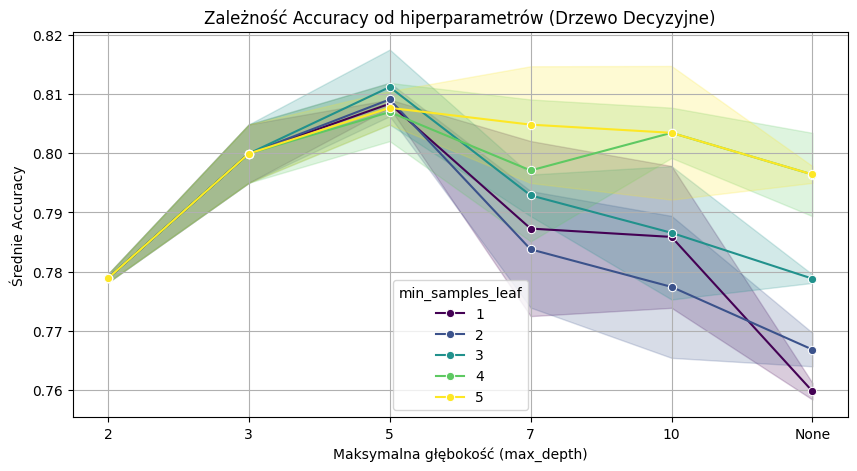

In [ ]:
tabela['max_depth'] = tabela['param_max_depth'].astype(str)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=tabela,
    x='max_depth',
    y='mean_test_accuracy',
    hue='param_min_samples_leaf',
    marker='o',
    palette='viridis'
)

plt.title('Zależność Accuracy od hiperparametrów (Drzewo Decyzyjne)')
plt.xlabel('Maksymalna głębokość (max_depth)')
plt.ylabel('Średnie Accuracy')
plt.legend(title='min_samples_leaf')
plt.grid(True)
plt.show()


Sposród możliwych parametrów najlepszą kombinacją jest maksymalna głębokość=5, minimalna ilość liści=3 i indeks ginniego jako kryterium podziału. Dokładność modelu z taką kombinacją dla walidacji krzyżowej to, aż *81,74%*, i jest znacząco większa od dokładności dla drzewa bez ustalonych parametrów. Precyzja wynosi *83,11%*, a czułość *67,44%*. Różnica dokładności między najlepszą a 10 najlepszą kombincajcą jest mniejsza niż std, dlatego ustawienia są nierozróżnialne, a najlepsze zostało takim przez przypadek.

Porównajmy więc teraz algorytm z najlepszymi hiperparamtrami do bazowego drzewa na zbiorze testowym i treningowym (cv pomijamy bo wyliczyliśmy je w tabeli).

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



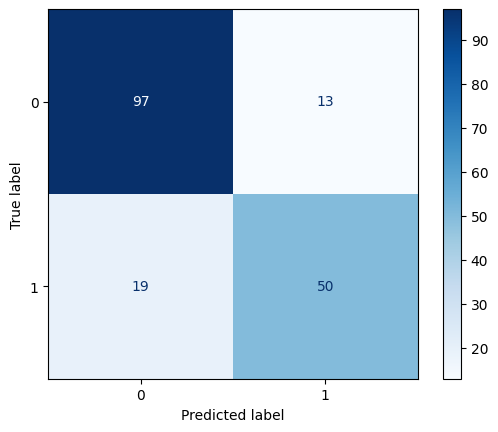

In [ ]:
model1_1 = DecisionTreeClassifier(max_depth=5,criterion="gini",min_samples_leaf=4,random_state=25)
model1_1.fit(X_train, y_train)
y_pred1 = model1_1.predict(X_test)
print(classification_report(y_test, y_pred1))
cm_1=confusion_matrix(y_test, y_pred1)
plot_confusion_matrix(cm_1,model1_1)

Dla naszych hiperparametrów na zbiorze testowym dokładność wynosi *82%*. Ponadto dla ocalałych precyzja wynosi *79%*, a czułość *72%*. Jednakże najważniejszym dla nas pytaniem będzie dokładność zbioru trenigowego.

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       439
           1       0.83      0.74      0.78       273

    accuracy                           0.84       712
   macro avg       0.84      0.82      0.83       712
weighted avg       0.84      0.84      0.84       712



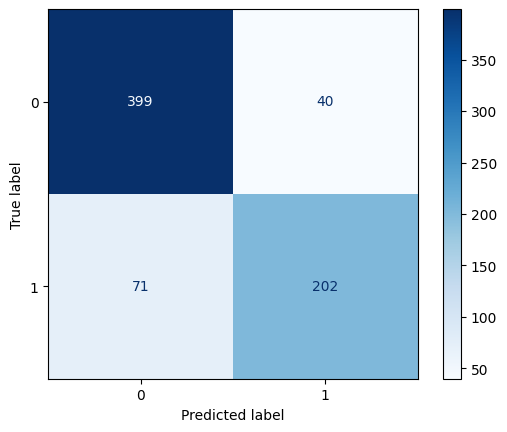

In [ ]:
y_pred1 = model1_1.predict(X_train)
print(classification_report(y_train, y_pred1))
cm_11=confusion_matrix(y_train, y_pred1)
plot_confusion_matrix(cm_11,model1_1)

Na szczęście na zbiorze treningowym dokładność wynosi *84%*. Ta różnica nie jest, aż tak drastyczna i nasz algorytm nie ma przeuczenia. Precyzja wzrosła do poziomu *83%*, a czułość do *74%*.

Ten przykład idealnie ukazał, jak ważna jest zmiana hiperparametrów, gdyż bez niej drzewa przeuczają się z łatwością. Przejdźmy teraz do drugiego modelu.

**2. SVM-Support Vector Machines**

Ten algorytm skupi się na szukaniu granicy decyzyjnej między cechami, która jak najlepiej oddzieli od siebie klasy, jednocześnie zachowywując przy tym jak największy margines. W przeciwieństwie do drzewa model będzie tworzył przestrzeń geometryczną jako podział, a nie kierował się sztywnymi regułami.

W tym modelu standaryzacja danych stanowczo wpłynie na zachowanie modelu. Różne wartości danych (np Fare a Age) wyraźnie wpłynęłyby na wyznaczania hiperpłaszczyny przez odmienne skale, przez co nasz model mógłby mieć gorzej wyznaczoną granicę decyzyjną.


              precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.71      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



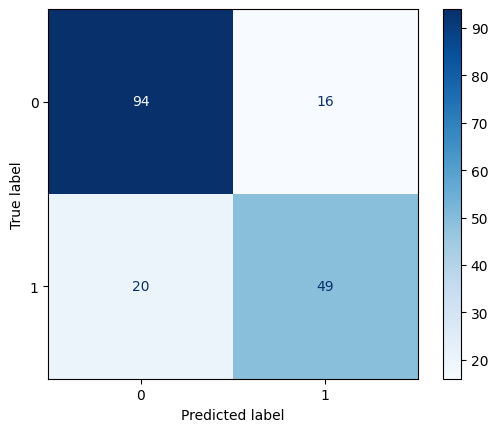

In [ ]:
scaler = StandardScaler()
clf = make_pipeline(scaler,SVC(random_state=25))
clf.fit(X_train, y_train)
ypred2= clf.predict(X_test)
print(classification_report(y_test, ypred2))
cm2=confusion_matrix(y_test, ypred2)
plot_confusion_matrix(cm2,clf)


Dla wektorów nośnych dokładność na zbiorze testowym wynosi *80%*. Precyzja dla tego zbioru wynosi *75%*, a czułość *71%*. Jak widać w zbiorze testowym tylko 36 (16 False Positovity + 20 False Negativity)pasażerów zostało błędnie sklasyfikowanych.

              precision    recall  f1-score   support

           0       0.85      0.88      0.87       439
           1       0.80      0.75      0.78       273

    accuracy                           0.83       712
   macro avg       0.83      0.82      0.82       712
weighted avg       0.83      0.83      0.83       712



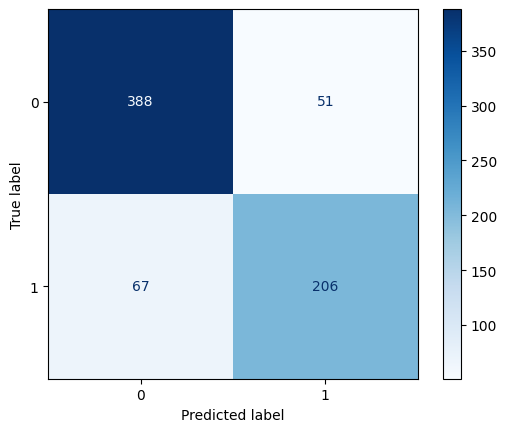

In [ ]:
ypred22 = clf.predict(X_train)
print(classification_report(y_train, ypred22))
cm22=confusion_matrix(y_train, ypred22)
plot_confusion_matrix(cm22,clf)


Jak widać na zbiorze treningowym, zarówno czułość, precyzja i dokładność procentowo zmieniły się. Dla tego zbioru wynoszą one teraz następująco *75%*, *80%* i *83%*. Tak mała różnica dokładności między zbiorem trenignowym a testowym świadczy o tym, że model się nie przeuczył i w miarę dobrze klasyfikuje dane.

Przejdźmy teraz do wyników surowego modelu dla walidacji krzyżowej (przy 5 foldach), aby sprawdzić nasz algorytm na bardziej złożonym zbiorze. Ponadto utworzę model bez dodatkowej standaryzacji dla porównania i sprawdzenia, czy wiedza teoretyczna jest też faktycznie widoczna w praktyce.

In [ ]:
#Łączymy do walidacji krzyżowej, ale mając na uwadze wcześniejsze uzuepełnienia braków danych
X_cv = pd.concat([X_train, X_test])
y_cv = pd.concat([y_train, y_test])
clf1=SVC(random_state=25)
wyniki = cross_val_score(clf, X_cv, y_cv, cv=5, scoring='accuracy')
wyniki_bez_skalowania=cross_val_score(clf1,X_cv,y_cv,cv=5,scoring='accuracy')
print(f"Wyniki {wyniki}")
print(f"srednia dla danych po standaryzacji: {wyniki.mean():.3f}  odchylenie: {wyniki.std():.3f}")
print(f"Wyniki bez standaryzacji {wyniki_bez_skalowania}")
print(f"srednia dla danych bez standaryzacji: {wyniki_bez_skalowania.mean():.3f}  odchylenie: {wyniki_bez_skalowania.std():.3f}")

Wyniki [0.80446927 0.80337079 0.82022472 0.79213483 0.80898876]
srednia dla danych po standaryzacji: 0.806  odchylenie: 0.009
Wyniki bez standaryzacji [0.68715084 0.65168539 0.69101124 0.6741573  0.67977528]
srednia dla danych bez standaryzacji: 0.677  odchylenie: 0.014


Widać, że nasz model jest raczej stabilny. Jego średnia dokładność dla walidacji wynosi *80,60%*, a odchylenie standardowe to zaledwie 0,009.

Przy okazji pokazłam, że standaryzacja jest konieczna, ponieważ bez tego dokładność walidacji krzyżowej dla naszego modelu spada do 67,7%. Ponadto odchylenie standardowe jest ponad trochę większe i algorytm jest niestabilny.

Aby wyniki klasyfikacji były bardziej satysfakcjonujące, możemy zmienić hiperparametry. Warto też zauważyć, że to właśnie dobór hiperparametrów może wpłynąć na potencjalne przetrenowanie modelu, dlatego musimy być ostrożni. Na pewno możemy skupić się na doborze jądra, które może być liniowe, wielomianowe, sigmoidalne lub radialne. Dodatkowym hiperparamtrem będzie paramter kosztu C, który nakłada na algorytm karę za błędną klasyfikację.

In [ ]:
siatka = {
    'svc__kernel':         ["linear", "poly", "rbf", "sigmoid"],
    'svc__C':              [0.1, 1, 5,10]
}
szukaj = GridSearchCV(
    clf,
    param_grid=siatka,
    cv=5,
    scoring=metryki,
    refit='accuracy'
)

szukaj.fit(X_train, y_train)
tabela1 = pd.DataFrame(szukaj.cv_results_)
tabela1 = tabela1[['param_svc__kernel', 'param_svc__C',
                 'mean_test_accuracy', 'mean_test_precision','mean_test_recall','std_test_accuracy']]
tabela1.sort_values('mean_test_accuracy', ascending=False).head(10)


,param_svc__kernel,param_svc__C,mean_test_accuracy,mean_test_precision,mean_test_recall,std_test_accuracy
14,rbf,10.0,0.804846,0.793036,0.670572,0.031377
6,rbf,1.0,0.804777,0.760397,0.721684,0.015613
10,rbf,5.0,0.803408,0.793118,0.666869,0.020874
13,poly,10.0,0.793578,0.755895,0.688822,0.016486
0,linear,0.1,0.789363,0.733460,0.710842,0.016712
8,linear,5.0,0.789353,0.735811,0.707138,0.016232
4,linear,1.0,0.789353,0.735811,0.707138,0.016232
3,sigmoid,0.1,0.789353,0.753023,0.681414,0.019515
12,linear,10.0,0.789353,0.735811,0.707138,0.016232
9,poly,5.0,0.786575,0.739066,0.688956,0.020496


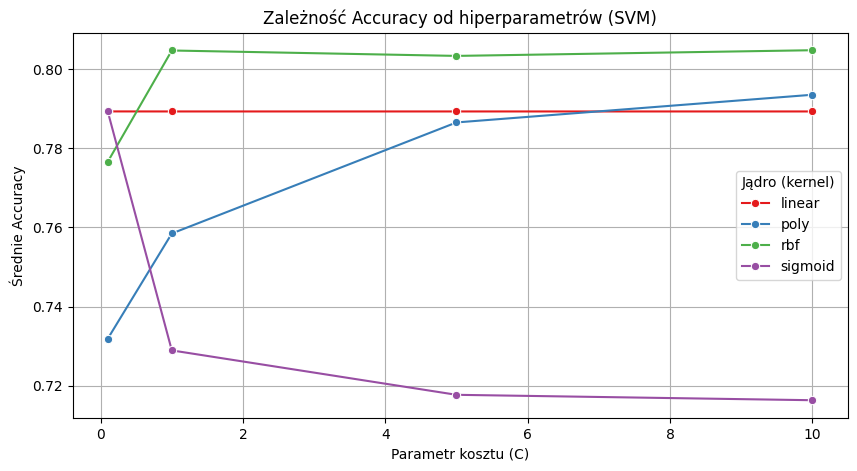

In [ ]:
svc_results = pd.DataFrame(szukaj.cv_results_)
plt.figure(figsize=(10, 5))
sns.lineplot(data=svc_results,x='param_svc__C',y='mean_test_accuracy',hue='param_svc__kernel', marker='o',palette='Set1')
plt.title('Zależność Accuracy od hiperparametrów (SVM)')
plt.xlabel('Parametr kosztu (C)')
plt.ylabel('Średnie Accuracy')
plt.legend(title='Jądro (kernel)')
plt.grid(True)
plt.show()


Najlepszą kombinacją hiperparametrów okazała się być mieszanka jądra radialnego i parametru kosztu równego 10. Jego dokładność dla walidacji krzyżowej wynosi dokładnie *80,48%*. Precyzja dla najlepszej kombincji wyniosła *79,3%*, a czułość *67.05%*. Jest to znaczący wzrost między podstawową wersją modelu. Warto zauważyć, że różnica między dokładnością najlepszej kombinacji a 10-tej jest większa i odchylenie standardowe. Świadczy to o tym, że parametry nie są losowe i po prostu są najlepsze dla tego modelu. Po doborze hiperparametrów wynik klasyfikacji jesteśmy w stanie uznać za dobry.

Sprawdźmy tylko jeszcze jak model zachowuje się na zbiorze testowym i trenigowym.

              precision    recall  f1-score   support

           0       0.82      0.92      0.87       110
           1       0.84      0.68      0.75        69

    accuracy                           0.83       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.83      0.83      0.82       179



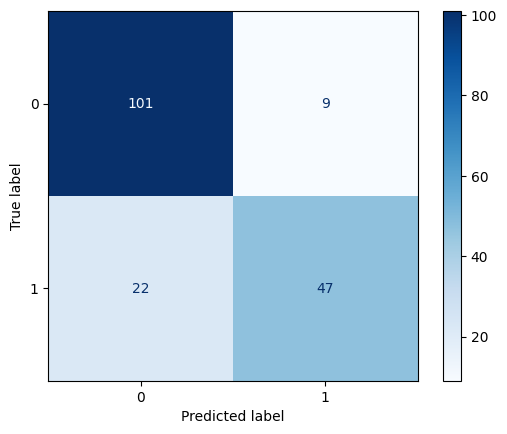

In [ ]:
model_2 = make_pipeline(scaler,SVC(kernel="rbf",C=10,random_state=25))
model_2.fit(X_train, y_train)
ypred2 = model_2.predict(X_test)
print(classification_report(y_test, ypred2))
cm_2=confusion_matrix(y_test, ypred2)
plot_confusion_matrix(cm_2,model_2)

Dokładność na pojedynczym zbiorze testowym wynosi *83%*. Precyzja to *84%*, a czulość *68%*.

              precision    recall  f1-score   support

           0       0.85      0.97      0.90       439
           1       0.93      0.73      0.81       273

    accuracy                           0.87       712
   macro avg       0.89      0.85      0.86       712
weighted avg       0.88      0.87      0.87       712



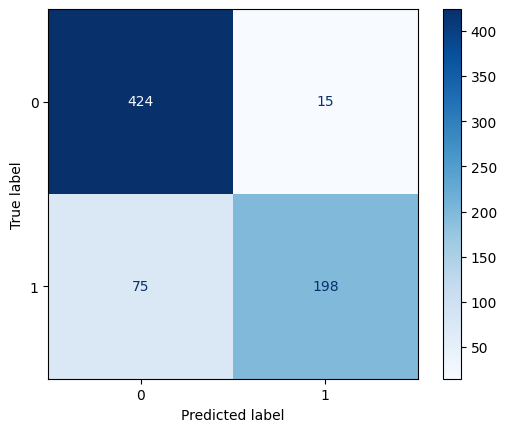

In [ ]:
y_pred22 = model_2.predict(X_train)
print(classification_report(y_train, y_pred22))
cm_22=confusion_matrix(y_train, y_pred22)
plot_confusion_matrix(cm_22,model_2)

Z kolei na trenigowym dokładność wzrosła do *87%*. Oznacza to, że model nie ma dużych tendencji do przeuczenia się i hiperparametry się nadają. ponadto precyzja wzrosła do *93%*, a czułość do *73%*.

Te wyniki utwierdzają tylko, iż nasz model jest dobrym klasyfikatorem.

# Wnioski



1.   Nasze modele są znacząco lepsze od naszego baselinu, co świadczy o tym, że nie musimy się martwić o modele
2.   Drzewo klasyfikacyjne jest bardzo łatwo podatne na przeuczenie, co udało się zaobserować. Wprowadzenie podstawowych ograniczeń przez hiperparametry pozwala na lepszą kontrolę modelu. Wyniki klasyfikacji dla walidacji krzyżowej po poprawie hiperparametrów były moim zdaniem już dobre.
3.   Metoda wektorów nośnych nie była aż tak podatna na przeuczenie. Nawet podstawowy model zwracał satysfakcjonujące wyniki klasyfikacji dla zbioru testowego i uczącego. Jednakże w przypadku walidacji krzyżowej wyniki były słabsze i dosyć przeciętne. Dobór hiperparametrów pozwolił na uzyskanie dobrych wyników klasyfikacji.
4. Porównanie najlepszych dotychczas modeli.



In [ ]:
for nazwa, m in [
    ("Drzewo", DecisionTreeClassifier(max_depth=5,criterion="gini",min_samples_leaf=4,random_state=25)),
    ("SVM", make_pipeline(scaler,SVC(kernel="rbf",C=10,random_state=25)))]:
    w = cross_val_score(m, X_cv, y_cv, cv=5)
    print(f"Dokładność {nazwa} {w.mean():.3f} +/- {w.std():.3f}")

for nazwa, m in [
    ("Drzewo", DecisionTreeClassifier(max_depth=5,criterion="gini",min_samples_leaf=4,random_state=25)),
    ("SVM", make_pipeline(scaler,SVC(kernel="rbf",C=10,random_state=25)))]:
    w = cross_val_score(m, X_cv, y_cv, cv=5,scoring='precision')
    print(f"Precyzja {nazwa} {w.mean():.3f} +/- {w.std():.3f}")

for nazwa, m in [
    ("Drzewo", DecisionTreeClassifier(max_depth=5,criterion="gini",min_samples_leaf=4,random_state=25)),
    ("SVM", make_pipeline(scaler,SVC(kernel="rbf",C=10,random_state=25)))]:
    w = cross_val_score(m, X_cv, y_cv, cv=5,scoring='recall')
    print(f"Czułość {nazwa} {w.mean():.3f} +/- {w.std():.3f}")



Dokładność Drzewo 0.811 +/- 0.010
Dokładność SVM 0.815 +/- 0.018
Precyzja Drzewo 0.814 +/- 0.073
Precyzja SVM 0.815 +/- 0.054
Czułość Drzewo 0.679 +/- 0.077
Czułość SVM 0.679 +/- 0.064


Jak więc widać na tych samych foldach SVM z jądrem radialnym i parametrem kosztu wynoszącym 10, jest lepszy od drzewa z najleszymi hiperparametrami. Jego precyzja jest o 0,01 lepsza, czułość jest identyczna, jednakże jest bardziej stabilna, bo odchylenie standardowe jest mniejsze, a dokładność lepsza o 0,04.